<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/edge_unet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import os

PROJECT_DIR = Path("/content/drive/MyDrive/Oil Spill/Final Detection model")
RAW_DATASET_DIR = Path("/content/drive/MyDrive/Oil Spill/Lados Dataset")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "processed").mkdir(exist_ok=True)
(PROJECT_DIR / "models").mkdir(exist_ok=True)
(PROJECT_DIR / "plots").mkdir(exist_ok=True)
(PROJECT_DIR / "tflite").mkdir(exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DATASET_DIR:", RAW_DATASET_DIR)
print("RAW exists:", RAW_DATASET_DIR.exists())

PROJECT_DIR: /content/drive/MyDrive/Oil Spill/Final Detection model
RAW_DATASET_DIR: /content/drive/MyDrive/Oil Spill/Lados Dataset
RAW exists: True


In [4]:
!pip install -q tensorflow opencv-python-headless seaborn scikit-learn matplotlib

In [5]:
import os
import cv2
import json
import shutil
import random
import time
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===== Updated config =====
SPILL_IDS = {2, 3, 5}

IMG_SIZE = 192
BATCH_SIZE = 8
INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5
EPOCHS_STAGE_1 = 30
EPOCHS_STAGE_2 = 20
MOBILENET_ALPHA = 0.75
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [6]:
def ensure_dirs(project_path: Path):
    for folder in ["processed", "models", "plots", "tflite"]:
        (project_path / folder).mkdir(parents=True, exist_ok=True)

    for split in ["train", "valid", "test"]:
        (project_path / "processed" / split / "images").mkdir(parents=True, exist_ok=True)
        (project_path / "processed" / split / "masks").mkdir(parents=True, exist_ok=True)

ensure_dirs(PROJECT_DIR)
print("Folders ready")

Folders ready


In [7]:
def get_image_mask_paths(project_path: Path, split_name: str):
    img_dir = project_path / "processed" / split_name / "images"
    mask_dir = project_path / "processed" / split_name / "masks"

    if not img_dir.exists() or not mask_dir.exists():
        raise FileNotFoundError(f"Missing processed split folders for: {split_name}")

    image_map = {
        Path(f).stem: str(img_dir / f)
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }
    mask_map = {
        Path(f).stem: str(mask_dir / f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    missing_masks = sorted(set(image_map) - set(mask_map))
    missing_images = sorted(set(mask_map) - set(image_map))
    if missing_masks or missing_images:
        raise ValueError(
            f"{split_name}: {len(missing_masks)} images without masks, "
            f"{len(missing_images)} masks without images"
        )

    paired_keys = sorted(image_map)
    if not paired_keys:
        raise ValueError(f"No processed pairs found for split: {split_name}")

    image_paths = [image_map[k] for k in paired_keys]
    mask_paths = [mask_map[k] for k in paired_keys]
    return image_paths, mask_paths


def convert_split_to_binary(raw_dataset_path: Path, project_path: Path, split_name: str):
    src_path = raw_dataset_path / split_name
    dst_img_path = project_path / "processed" / split_name / "images"
    dst_mask_path = project_path / "processed" / split_name / "masks"

    if not src_path.exists():
        raise FileNotFoundError(f"Missing split folder: {src_path}")

    files = sorted(os.listdir(src_path))
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_mask" not in f.lower()
    ]

    total_images = 0
    total_masks = 0

    for img_file in image_files:
        base = Path(img_file).stem
        mask_file = f"{base}_mask.png"

        img_src = src_path / img_file
        mask_src = src_path / mask_file

        if not mask_src.exists():
            continue

        img = cv2.imread(str(img_src))
        mask = cv2.imread(str(mask_src), cv2.IMREAD_UNCHANGED)

        if img is None or mask is None:
            continue

        binary_mask = np.isin(mask, list(SPILL_IDS)).astype(np.uint8)

        cv2.imwrite(str(dst_img_path / img_file), img)
        cv2.imwrite(str(dst_mask_path / f"{base}.png"), binary_mask * 255)

        total_images += 1
        total_masks += 1

    print(f"{split_name}: saved {total_images} images and {total_masks} masks")


def maybe_prepare_processed_data(raw_dataset_path: Path, project_path: Path):
    ensure_dirs(project_path)

    for split in ["train", "valid", "test"]:
        try:
            image_paths, mask_paths = get_image_mask_paths(project_path, split)
            if image_paths and mask_paths:
                print(f"[skip] processed already exists for: {split}")
                continue
        except Exception:
            pass

        print(f"[prepare] converting split: {split}")
        convert_split_to_binary(raw_dataset_path, project_path, split)
        _ = get_image_mask_paths(project_path, split)

maybe_prepare_processed_data(RAW_DATASET_DIR, PROJECT_DIR)

[prepare] converting split: train
train: saved 2370 images and 2370 masks
[prepare] converting split: valid
valid: saved 675 images and 675 masks
[prepare] converting split: test
test: saved 343 images and 343 masks


In [8]:
for split in ["train", "valid", "test"]:
    image_paths, mask_paths = get_image_mask_paths(PROJECT_DIR, split)
    print(f"{split}: {len(image_paths)} images, {len(mask_paths)} masks")

train: 2370 images, 2370 masks
valid: 675 images, 675 masks
test: 343 images, 343 masks


In [9]:
def read_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image

def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask > 127, tf.float32)
    return mask

def augment_pair(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    # light photometric augmentation
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.92, upper=1.08)

    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.02, dtype=tf.float32)
    image = image + noise
    image = tf.clip_by_value(image, -1.0, 1.0)

    return image, mask

def load_pair(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask

def make_dataset(image_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(min(len(image_paths), 512), reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [10]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

bce_focal = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

def focal_dice_loss(y_true, y_pred):
    focal = bce_focal(y_true, y_pred)
    dloss = dice_loss(y_true, y_pred)
    return 0.4 * focal + 0.6 * dloss

In [11]:
def sep_conv_block(x, filters, dropout=0.0):
    x = tf.keras.layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout)(x)

    return x

def build_edge_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=MOBILENET_ALPHA):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        alpha=alpha
    )

    skip_names = [
        "block_1_expand_relu",
        "block_3_expand_relu",
        "block_6_expand_relu",
        "block_13_expand_relu",
        "block_16_project",
    ]

    skip_outputs = [base.get_layer(name).output for name in skip_names]
    encoder = tf.keras.Model(base.input, skip_outputs, name="mobilenetv2_encoder")
    encoder.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    s1, s2, s3, s4, bottleneck = encoder(inputs, training=False)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(bottleneck)
    x = tf.keras.layers.Concatenate()([x, s4])
    x = sep_conv_block(x, 128, dropout=0.08)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s3])
    x = sep_conv_block(x, 96, dropout=0.08)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s2])
    x = sep_conv_block(x, 64, dropout=0.05)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, s1])
    x = sep_conv_block(x, 32, dropout=0.03)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = sep_conv_block(x, 16, dropout=0.02)

    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)
    return tf.keras.Model(inputs, outputs, name="Edge_UNet_Lite_Improved")

def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_dice_loss,
        metrics=[
            dice_coef,
            tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
        ],
    )

def unfreeze_last_encoder_layers(model, n_last_layers=30):
    encoder = model.get_layer("mobilenetv2_encoder")
    for layer in encoder.layers[:-n_last_layers]:
        layer.trainable = False
    for layer in encoder.layers[-n_last_layers:]:
        layer.trainable = True

def build_callbacks(save_path, monitor="val_dice_coef"):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(save_path),
            monitor=monitor,
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            verbose=1,
        ),
    ]

In [12]:
train_image_paths, train_mask_paths = get_image_mask_paths(PROJECT_DIR, "train")
valid_image_paths, valid_mask_paths = get_image_mask_paths(PROJECT_DIR, "valid")
test_image_paths, test_mask_paths = get_image_mask_paths(PROJECT_DIR, "test")

train_ds = make_dataset(train_image_paths, train_mask_paths, training=True)
valid_ds = make_dataset(valid_image_paths, valid_mask_paths, training=False)
test_ds  = make_dataset(test_image_paths, test_mask_paths, training=False)

print("Train:", len(train_image_paths))
print("Valid:", len(valid_image_paths))
print("Test :", len(test_image_paths))

Train: 2370
Valid: 675
Test : 343


In [13]:
model = build_edge_unet()
compile_model(model, INITIAL_LR)
model.summary()

5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Edge_UNet_Lite_Improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 96, 96,   │  1,068,784 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 48,   │            │                   │
│                     │ 48, 144), (None,  │            │                   │
│                     │ 24, 24, 144),     │            │                   │
│                     │ (None, 12, 12,    │            │                   │
│                     │ 432), (None, 6,   │            │                   │
│                     │ 6, 240)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 12, 12,    │          0 │ mobilenetv2_enco… │
│ (UpSampling2D)      │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12, 12,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 672)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 12, 12,    │     92,064 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 12,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 12, 12,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 12, 12,    │     17,536 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 12, 12,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 12,    │          0 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 24, 24,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24, 24,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 272)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 24, 24,    │     28,560 │ concatenate_1[0]… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                 

 Total params: 1,250,993 (4.77 MB)

 Trainable params: 180,865 (706.50 KB)

 Non-trainable params: 1,070,128 (4.08 MB)

In [14]:
stage1_path = PROJECT_DIR / "models" / "edge_unet_stage1_best.keras"
stage2_path = PROJECT_DIR / "models" / "edge_unet_stage2_best.keras"
final_model_path = PROJECT_DIR / "models" / "edge_unet_final.keras"

history_stage1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=build_callbacks(stage1_path),
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4734 - dice_coef: 0.3914 - iou: 0.2889 - loss: 0.5070 - precision: 0.3107 - recall: 0.8047
Epoch 1: val_dice_coef improved from None to 0.27697, saving model to /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage1_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.5529 - dice_coef: 0.3581 - iou: 0.2836 - loss: 0.5041 - precision: 0.3060 - recall: 0.7952 - val_accuracy: 0.5176 - val_dice_coef: 0.2770 - val_iou: 0.2042 - val_loss: 0.5049 - val_precision: 0.2494 - val_recall: 0.5299 - learning_rate: 1.0000e-04
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7327 - dice_coef: 0.4314 - iou: 0.3973 - loss: 0.4152 - precision: 0.4870 - recall: 0.6825
Epoch 2: val_dice_coef improved from 0.27697 to 0.30286, saving model to /content/drive/MyDrive/Oil

In [15]:
model.load_weights(str(stage1_path))
unfreeze_last_encoder_layers(model, n_last_layers=30)
compile_model(model, FINE_TUNE_LR)

history_stage2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=build_callbacks(stage2_path),
)

model.save(str(final_model_path))
print("Saved final model:", final_model_path)

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8480 - dice_coef: 0.6108 - iou: 0.5298 - loss: 0.3213 - precision: 0.7367 - recall: 0.6547
Epoch 1: val_dice_coef improved from None to 0.53105, saving model to /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage2_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 528s 2s/step - accuracy: 0.8633 - dice_coef: 0.5838 - iou: 0.5300 - loss: 0.3241 - precision: 0.6933 - recall: 0.6924 - val_accuracy: 0.9013 - val_dice_coef: 0.5310 - val_iou: 0.6433 - val_loss: 0.3314 - val_precision: 0.8054 - val_recall: 0.7616 - learning_rate: 1.0000e-05
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8573 - dice_coef: 0.6344 - iou: 0.5647 - loss: 0.2967 - precision: 0.7591 - recall: 0.6900
Epoch 2: val_dice_coef improved from 0.53105 to 0.53326, saving model to /content/drive/MyDrive/Oil

In [16]:
history_path = PROJECT_DIR / "models" / "training_history.npz"
np.savez(
    str(history_path),
    history_stage1=history_stage1.history,
    history_stage2=history_stage2.history,
)
print("Saved history:", history_path)

Saved history: /content/drive/MyDrive/Oil Spill/Final Detection model/models/training_history.npz


In [17]:
MODEL_PATH = stage2_path if stage2_path.exists() else stage1_path
print("Using model:", MODEL_PATH)

best_model = tf.keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef,
    },
)

Using model: /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage2_best.keras


In [18]:
results = best_model.evaluate(test_ds, verbose=1)
metrics = dict(zip(best_model.metrics_names, results))
print("\n=== Test Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 498ms/step - accuracy: 0.8787 - dice_coef: 0.5710 - iou: 0.6474 - loss: 0.3264 - precision: 0.7164 - recall: 0.8704

=== Test Metrics ===
loss: 0.326403
compile_metrics: 0.571040


In [20]:
def compute_metrics_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    def safe_div(a, b):
        return float(a / b) if b else 0.0

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": safe_div(tp + tn, total),
        "precision": safe_div(tp, tp + fp),
        "recall": safe_div(tp, tp + fn),
        "specificity": safe_div(tn, tn + fp),
        "iou": safe_div(tp, tp + fp + fn),
        "dice": safe_div(2 * tp, 2 * tp + fp + fn),
        "true_positive_ratio": safe_div(tp + fn, total),
        "pred_positive_ratio": safe_div(tp + fp, total),
    }

def gather_predictions(model, dataset):
    all_true = []
    all_pred_prob = []

    for images, masks in dataset:
        preds = model.predict(images, verbose=0)
        all_true.append(masks.numpy().astype(np.uint8).flatten())
        all_pred_prob.append(preds.flatten())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_pred_prob)
    return y_true, y_prob

y_true, y_prob = gather_predictions(best_model, test_ds)

thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
threshold_results = []

for th in thresholds:
    y_pred = (y_prob > th).astype(np.uint8)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    m = compute_metrics_from_cm(cm)
    m["threshold"] = th
    threshold_results.append(m)

threshold_results = sorted(threshold_results, key=lambda x: (x["dice"], x["accuracy"]), reverse=True)

for row in threshold_results:
    print(row)

{'tn': 8666009, 'fp': 743218, 'fn': 591930, 'tp': 2643195, 'accuracy': 0.8944075584102689, 'precision': 0.7805294274502254, 'recall': 0.8170302538541787, 'specificity': 0.9210117898101512, 'iou': 0.6643959558037102, 'dice': 0.7983628576925784, 'true_positive_ratio': 0.25585534157859574, 'pred_positive_ratio': 0.26782020937095075, 'threshold': 0.65}
{'tn': 8760726, 'fp': 648501, 'fn': 657342, 'tp': 2577783, 'accuracy': 0.8967251939838435, 'precision': 0.7989944468620865, 'recall': 0.7968109423901704, 'specificity': 0.9310781852749435, 'iou': 0.6637567572160656, 'dice': 0.7979012008062019, 'true_positive_ratio': 0.25585534157859574, 'pred_positive_ratio': 0.25515613611516036, 'threshold': 0.7}
{'tn': 8558005, 'fp': 851222, 'fn': 530371, 'tp': 2704754, 'accuracy': 0.8907343768980807, 'precision': 0.760622118934436, 'recall': 0.836058575789189, 'specificity': 0.9095332698424642, 'iou': 0.6619002253112621, 'dice': 0.7965583194831, 'true_positive_ratio': 0.25585534157859574, 'pred_positive_r

In [21]:
best_threshold = threshold_results[0]["threshold"]
print("Best threshold:", best_threshold)

Best threshold: 0.65


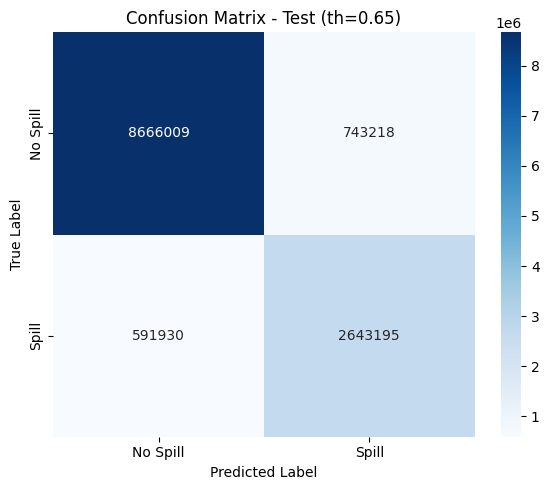

Saved: /content/drive/MyDrive/Oil Spill/Final Detection model/plots/confusion_matrix_test_best_threshold.png


In [22]:
best_pred = (y_prob > best_threshold).astype(np.uint8)
cm = confusion_matrix(y_true, best_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Spill", "Spill"],
    yticklabels=["No Spill", "Spill"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Test (th={best_threshold})")
plt.tight_layout()

cm_path = PROJECT_DIR / "plots" / "confusion_matrix_test_best_threshold.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [23]:
qual_dir = PROJECT_DIR / "plots" / "qualitative_predictions_best"
qual_dir.mkdir(parents=True, exist_ok=True)

for images, masks in test_ds.take(1):
    preds = best_model.predict(images, verbose=0)
    preds = (preds > best_threshold).astype(np.float32)

    for i in range(min(5, images.shape[0])):
        plt.figure(figsize=(10, 3.5))

        plt.subplot(1, 3, 1)
        plt.imshow((images[i].numpy() + 1.0) / 2.0)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(preds[i].squeeze(), cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.tight_layout()
        save_path = qual_dir / f"prediction_{i+1}.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()

print("Saved qualitative predictions to:", qual_dir)

Saved qualitative predictions to: /content/drive/MyDrive/Oil Spill/Final Detection model/plots/qualitative_predictions_best


In [24]:
best_metrics = threshold_results[0]

report = {
    "model_path": str(MODEL_PATH),
    "img_size": IMG_SIZE,
    "mobilenet_alpha": MOBILENET_ALPHA,
    "best_threshold": best_threshold,
    "metrics": best_metrics,
    "all_threshold_results": threshold_results,
}

report_path = PROJECT_DIR / "metrics_best_threshold.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved:", report_path)

Saved: /content/drive/MyDrive/Oil Spill/Final Detection model/metrics_best_threshold.json


In [25]:
def remove_small_components(mask, min_area=40):
    mask_uint8 = (mask * 255).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)

    cleaned = np.zeros_like(mask_uint8)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == i] = 255

    return (cleaned > 127).astype(np.uint8)

In [26]:
def make_representative_data_gen(train_ds, max_batches=50):
    def representative_data_gen():
        for images, _ in train_ds.take(max_batches):
            images_np = images.numpy()
            for i in range(images_np.shape[0]):
                yield [images_np[i:i+1].astype(np.float32)]
    return representative_data_gen

In [27]:
saved_model_dir = PROJECT_DIR / "tflite" / "saved_model"

if saved_model_dir.exists():
    shutil.rmtree(saved_model_dir)

if hasattr(best_model, "export"):
    best_model.export(str(saved_model_dir))
else:
    input_spec = tf.TensorSpec(shape=[None, IMG_SIZE, IMG_SIZE, 3], dtype=tf.float32, name="inputs")

    @tf.function(input_signature=[input_spec])
    def serving_fn(inputs):
        return best_model(inputs, training=False)

    tf.saved_model.save(best_model, str(saved_model_dir), signatures={"serving_default": serving_fn})

print("SavedModel exported:", saved_model_dir)

Saved artifact at '/content/drive/MyDrive/Oil Spill/Final Detection model/tflite/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 192, 192, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 192, 192, 1), dtype=tf.float32, name=None)
Captures:
  134384995771664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995765712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995768016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995772240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995772048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995771856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995768592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995768400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134384995771088:

In [28]:
def file_size_mb(path):
    return path.stat().st_size / (1024 * 1024)

int8_path = PROJECT_DIR / "tflite" / "edge_unet_lite_int8.tflite"
fp16_path = PROJECT_DIR / "tflite" / "edge_unet_lite_fp16.tflite"

# INT8
converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = make_representative_data_gen(train_ds)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
with open(int8_path, "wb") as f:
    f.write(tflite_model)

print("Saved:", int8_path)
print("INT8 Size:", file_size_mb(int8_path), "MB")

# FP16
converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()
with open(fp16_path, "wb") as f:
    f.write(tflite_model)

print("Saved:", fp16_path)
print("FP16 Size:", file_size_mb(fp16_path), "MB")

Saved: /content/drive/MyDrive/Oil Spill/Final Detection model/tflite/edge_unet_lite_int8.tflite
INT8 Size: 1.5843124389648438 MB
Saved: /content/drive/MyDrive/Oil Spill/Final Detection model/tflite/edge_unet_lite_fp16.tflite
FP16 Size: 2.3819808959960938 MB


In [29]:
def quick_tflite_test(model_path, sample_input):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_scale, input_zero_point = input_details[0]["quantization"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    x = sample_input.copy()

    if input_details[0]["dtype"] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    else:
        x = x.astype(input_details[0]["dtype"])

    start = time.time()
    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()
    elapsed_ms = (time.time() - start) * 1000

    output = interpreter.get_tensor(output_details[0]["index"])

    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero_point) * output_scale

    print(f"{Path(model_path).name}")
    print(f"Inference time: {elapsed_ms:.2f} ms")
    print(f"Output shape  : {output.shape}")
    print(f"Output min/max: {output.min():.4f} / {output.max():.4f}")

for images, _ in train_ds.take(1):
    sample_input = images[:1].numpy()
    quick_tflite_test(int8_path, sample_input)
    quick_tflite_test(fp16_path, sample_input)
    break

edge_unet_lite_int8.tflite
Inference time: 40.42 ms
Output shape  : (1, 192, 192, 1)
Output min/max: 0.0000 / 0.4492
edge_unet_lite_fp16.tflite
Inference time: 30.50 ms
Output shape  : (1, 192, 192, 1)
Output min/max: 0.0013 / 0.4108


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [30]:
summary_path = PROJECT_DIR / "OUTPUT_SUMMARY_UPDATED.md"

summary_text = f"""
# Updated Edge Model Output Summary

## Training setup
- IMG_SIZE: {IMG_SIZE}
- MobileNet alpha: {MOBILENET_ALPHA}
- Stage 1 epochs: {EPOCHS_STAGE_1}
- Stage 2 epochs: {EPOCHS_STAGE_2}
- Initial LR: {INITIAL_LR}
- Fine-tune LR: {FINE_TUNE_LR}

## Best model
- Model path: {MODEL_PATH}

## Best threshold
- {best_threshold}

## Best metrics
- Accuracy: {best_metrics['accuracy']:.6f}
- Precision: {best_metrics['precision']:.6f}
- Recall: {best_metrics['recall']:.6f}
- Specificity: {best_metrics['specificity']:.6f}
- IoU: {best_metrics['iou']:.6f}
- Dice: {best_metrics['dice']:.6f}

## Confusion counts
- TN: {best_metrics['tn']}
- FP: {best_metrics['fp']}
- FN: {best_metrics['fn']}
- TP: {best_metrics['tp']}

## Files
- {cm_path}
- {qual_dir}
- {report_path}
- {int8_path}
- {fp16_path}
"""

summary_path.write_text(summary_text, encoding="utf-8")
print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/Oil Spill/Final Detection model/OUTPUT_SUMMARY_UPDATED.md

# Updated Edge Model Output Summary

## Training setup
- IMG_SIZE: 192
- MobileNet alpha: 0.75
- Stage 1 epochs: 30
- Stage 2 epochs: 20
- Initial LR: 0.0001
- Fine-tune LR: 1e-05

## Best model
- Model path: /content/drive/MyDrive/Oil Spill/Final Detection model/models/edge_unet_stage2_best.keras

## Best threshold
- 0.65

## Best metrics
- Accuracy: 0.894408
- Precision: 0.780529
- Recall: 0.817030
- Specificity: 0.921012
- IoU: 0.664396
- Dice: 0.798363

## Confusion counts
- TN: 8666009
- FP: 743218
- FN: 591930
- TP: 2643195

## Files
- /content/drive/MyDrive/Oil Spill/Final Detection model/plots/confusion_matrix_test_best_threshold.png
- /content/drive/MyDrive/Oil Spill/Final Detection model/plots/qualitative_predictions_best
- /content/drive/MyDrive/Oil Spill/Final Detection model/metrics_best_threshold.json
- /content/drive/MyDrive/Oil Spill/Final Detection model/tflite/edge_unet_lite_int8.